
# Predicción de precios de acciones con un agente de aprendizaje por refuerzo






## 1. Instalación de librerías

El documento original menciona la librería `yahoo_finance`.  
Sin embargo, esta librería se encuentra **obsoleta**.

### Código original

```python
from yahoo_finance import Share
msft = Share("MSFT")
print(msft.get_open())
```

### Modificación realizada

Se reemplaza por **yfinance**, que permite obtener datos históricos actualizados.

```python
import yfinance as yf
```

**Justificación:**

- yahoo_finance ya no recibe mantenimiento.
- yfinance es actualmente el estándar para obtener datos de Yahoo Finance.
- Permite descargar datos históricos fácilmente.


In [1]:
!pip install yfinance numpy pandas matplotlib

## 2. Importar librerías

In [2]:

import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import random



## 3. Obtener precios históricos

Se descargan datos reales de Microsoft (MSFT).
Se utiliza un rango amplio de fechas para obtener suficiente información del mercado.


In [3]:

def get_prices(symbol, start, end):
    data = yf.download(symbol, start=start, end=end, auto_adjust=True)
    return data["Open"].to_numpy().flatten()

prices = get_prices("MSFT","2015-01-01","2025-01-01")

print("Número de precios descargados:", len(prices))
print("Dimensión del vector:", prices.shape)


[*********************100%***********************]  1 of 1 completed

Número de precios descargados: 2516
Dimensión del vector: (2516,)


## 4. Visualización de precios históricos

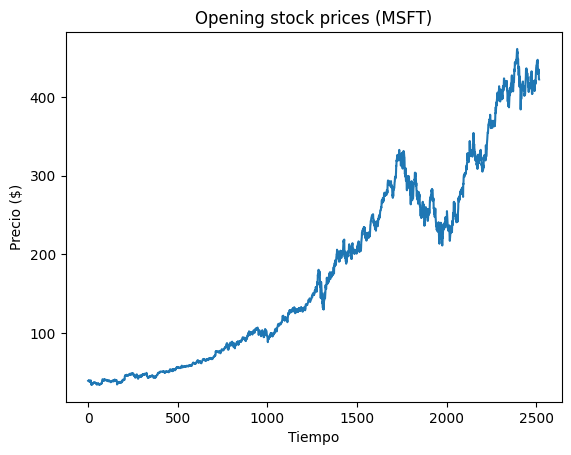

In [4]:

plt.figure()
plt.title("Opening stock prices (MSFT)")
plt.xlabel("Tiempo")
plt.ylabel("Precio ($)")
plt.plot(prices)
plt.show()



## 5. Clase base de política de decisión

Se define una clase base para representar la política del agente.


In [5]:

class DecisionPolicy:
    
    def select_action(self, current_state, step):
        pass

    def update_q(self, state, action, reward, next_state):
        pass



## 6. Política aleatoria

Primero se implementa una política simple que elige acciones aleatoriamente.
Esto permite probar el entorno antes de implementar algoritmos de aprendizaje más complejos.


In [6]:

class RandomDecisionPolicy(DecisionPolicy):

    def __init__(self, actions):
        self.actions = actions

    def select_action(self, current_state, step):
        return random.choice(self.actions)



## 7. Simulación del trading

Se simula el comportamiento del agente a lo largo del tiempo.
En cada paso el agente puede:

- Comprar una acción
- Vender una acción
- Mantener su posición


In [7]:

def run_simulation(policy, initial_budget, initial_num_stocks, prices, hist=200):

    if len(prices) <= hist:
        raise ValueError("No hay suficientes datos para el historial seleccionado")

    budget = initial_budget
    num_stocks = initial_num_stocks

    for i in range(hist, len(prices)-1):

        current_state = np.hstack((prices[i-hist:i], [budget, num_stocks]))
        action = policy.select_action(current_state, i)

        share_value = prices[i]

        current_portfolio = budget + num_stocks * share_value

        if action == "Buy" and budget >= share_value:
            budget -= share_value
            num_stocks += 1

        elif action == "Sell" and num_stocks > 0:
            budget += share_value
            num_stocks -= 1

        new_portfolio = budget + num_stocks * share_value
        reward = new_portfolio - current_portfolio

    portfolio = budget + num_stocks * prices[-1]

    return portfolio



## 8. Ejecutar múltiples simulaciones

Debido a que la política es aleatoria, una sola simulación no es suficiente.
Por ello se ejecuta el experimento **100 veces** para calcular:

- Portafolio promedio
- Desviación estándar


In [8]:

def run_simulations(policy, budget, num_stocks, prices, hist):

    num_tries = 100
    final_portfolios = []

    for _ in range(num_tries):
        result = run_simulation(policy, budget, num_stocks, prices, hist)
        final_portfolios.append(result)

    avg = np.mean(final_portfolios)
    std = np.std(final_portfolios)

    return avg, std


## 9. Evaluación del agente

In [9]:

actions = ["Buy","Sell","Hold"]

policy = RandomDecisionPolicy(actions)

budget = 1000
num_stocks = 0
hist = 200

avg, std = run_simulations(policy, budget, num_stocks, prices, hist)

print("Portafolio promedio final:", avg)
print("Desviación estándar:", std)


Portafolio promedio final: 3158.3811011061516
Desviación estándar: 867.9182367340778



# 10. Análisis de resultados

El experimento utiliza una **política de decisión aleatoria**, lo que significa que el agente no toma decisiones basadas en el comportamiento del mercado.

## Observaciones

Durante las simulaciones se observa que:

- El portafolio final cambia en cada ejecución.
- La desviación estándar suele ser elevada.
- Algunas simulaciones generan ganancias mientras otras generan pérdidas.

Esto ocurre porque las decisiones del agente no están basadas en información del mercado, sino en elecciones aleatorias.

## Interpretación

El experimento demuestra que:

- Es posible modelar el proceso de trading como un problema de **aprendizaje por refuerzo**.
- El estado del agente está compuesto por:
  - historial de precios
  - presupuesto disponible
  - número de acciones

Sin embargo, una política aleatoria **no es suficiente para obtener resultados consistentes**.

## Conclusión

Para mejorar el rendimiento del agente sería necesario implementar métodos más avanzados como:

- Q‑Learning
- Redes neuronales
- Estrategias de exploración como epsilon‑greedy

Estos métodos permitirían que el agente aprenda patrones en los datos históricos y tome decisiones más eficientes para maximizar la ganancia del portafolio.
